In [2]:
! pip install nltk

In [ ]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import re

import nltk
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer

import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional,
)

import warnings

warnings.filterwarnings("ignore")


In [ ]:
train_data = pd.read_csv("/content/DataSet/training.csv")
test_data = pd.read_csv("/content/DataSet/test.csv")
validation_data = pd.read_csv("/content/DataSet/validation.csv")

In [ ]:
print("Train_data :\n", train_data.head(), "\n")
print("Test_data :\n", test_data.head(), "\n")
print("Validation_data :\n", validation_data.head(), "\n")

Train_data :
                                                 text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3 

Test_data :
                                                 text  label
0  im feeling rather rotten so im not very ambiti...      0
1          im updating my blog because i feel shitty      0
2  i never make her separate from me because i do...      0
3  i left with my bouquet of red and yellow tulip...      1
4    i was feeling a little vain when i did this one      0 

Validation_data :
                                                 text  label
0  im feeling quite sad and sorry for myself but ...      0
1  i feel like i am still looking at a blank canv...      0
2                     i feel like a faithful serva

In [ ]:
print("Training Data Shape :", train_data.shape)
print("Test Data Shape :", test_data.shape)
print("Validation Data Shape :", validation_data.shape)


Training Data Shape : (16000, 2)
Test Data Shape : (2000, 2)
Validation Data Shape : (2000, 2)


In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB


In [9]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2000 non-null   object
 1   label   2000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


In [10]:
validation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2000 non-null   object
 1   label   2000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


In [11]:
train_data.describe()

,label
count,16000.000000
mean,1.565937
std,1.501430
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [ ]:
train_data.describe(include="all")

,text,label
count,16000,16000.000000
unique,15969,NaN
top,im still not sure why reilly feels the need to...,NaN
freq,2,NaN
mean,NaN,1.565937
std,NaN,1.501430
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,1.000000
75%,NaN,3.000000


In [ ]:
train_data["label"].value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


<Axes: xlabel='label'>

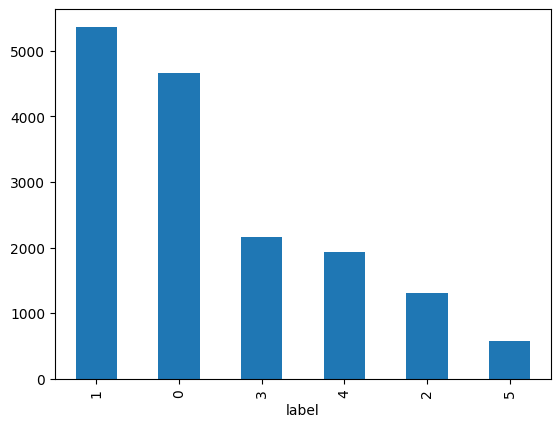

In [ ]:
train_data["label"].value_counts().plot(kind="bar")

In [ ]:
print("Number of Null values in the training dataset is :", train_data.isna().sum())
print(
    "Number of Duplicate values in the training dataset is :",
    train_data.duplicated().sum(),
)


Number of Null values in the training dataset is : text     0
label    0
dtype: int64
Number of Duplicate values in the training dataset is : 1


In [ ]:
train_data.drop_duplicates(keep="first", inplace=True)

In [ ]:
print(
    "Now the number of duplicates in the training dataset are :",
    train_data.duplicated().sum(),
)
print("Now the shape of the training dataset is :", train_data.shape)


Now the number of duplicates in the training dataset are : 0
Now the shape of the training dataset is : (15999, 2)


In [ ]:
nltk.download("stopwords")
pattern = re.compile("<.*?>")
punctuation = string.punctuation
ps = PorterStemmer()
tokenizer = Tokenizer()


def text_preprocessing(text):
    text = re.sub(pattern, "", text)  ## removing the html tags
    text = text.lower()  ## lowering the words
    text = text.translate(
        str.maketrans("", "", punctuation)
    )  ## removing the punctuations

    text = text.split()  ## word tokenize
    text = [
        ps.stem(word) for word in text if word not in stopwords.words("english")
    ]  ## removing the stopwords and stemming the word to their root form

    return " ".join(text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
processed_train_data = [text_preprocessing(words) for words in train_data["text"]]
processed_validation_data = [
    text_preprocessing(words) for words in validation_data["text"]
]
processed_test_data = [text_preprocessing(words) for words in test_data["text"]]

In [ ]:
whole_text = ""
for word in processed_train_data:
    whole_text += word

tokenizer.fit_on_texts([whole_text])
print(len(tokenizer.word_index))

20360


In [ ]:
tokenizer.word_index
## It counts how many times each word appears. The most frequent word gets assigned the index 1, the second most frequent 2, and so on.

{'feel': 1,
 'like': 2,
 'im': 3,
 'make': 4,
 'get': 5,
 'time': 6,
 'realli': 7,
 'go': 8,
 'littl': 9,
 'peopl': 10,
 'want': 11,
 'know': 12,
 'thing': 13,
 'one': 14,
 'love': 15,
 'even': 16,
 'would': 17,
 'bit': 18,
 'day': 19,
 'think': 20,
 'someth': 21,
 'much': 22,
 'way': 23,
 'life': 24,
 'need': 25,
 'still': 26,
 'work': 27,
 'pretti': 28,
 'back': 29,
 'dont': 30,
 'say': 31,
 'look': 32,
 'see': 33,
 'good': 34,
 'tri': 35,
 'could': 36,
 'come': 37,
 'start': 38,
 'take': 39,
 'help': 40,
 'ive': 41,
 'friend': 42,
 'year': 43,
 'made': 44,
 'around': 45,
 'though': 46,
 'use': 47,
 'someon': 48,
 'everi': 49,
 'lot': 50,
 'person': 51,
 'less': 52,
 'quit': 53,
 'alway': 54,
 'mani': 55,
 'right': 56,
 'write': 57,
 'today': 58,
 'well': 59,
 'enough': 60,
 'give': 61,
 'happi': 62,
 'kind': 63,
 'live': 64,
 'never': 65,
 'long': 66,
 'find': 67,
 'last': 68,
 'thought': 69,
 'without': 70,
 'felt': 71,
 'also': 72,
 'support': 73,
 'sure': 74,
 'got': 75,
 'let': 

In [ ]:
## texts_to_sequences(text): This is the step that replaces each word with its corresponding number from that dictionary, turning your sentence into a list of integers

x_train_sequences = []
for word in processed_train_data:
    x_train_sequences.append(tokenizer.texts_to_sequences([word])[0])

x_train_padseq = pad_sequences(x_train_sequences, maxlen=50, padding="post")

x_train = np.array(x_train_padseq)
y_train = np.array(to_categorical(train_data["label"]))

In [ ]:
x_validation_sequences = []

for i in processed_validation_data:
    x_validation_sequences.append(tokenizer.texts_to_sequences([i])[0])

x_validation_padseq = pad_sequences(x_validation_sequences, maxlen=50, padding="post")

x_validation = np.array(x_validation_padseq)
y_validation = np.array(to_categorical(validation_data["label"]))

In [26]:
x_test_sequences = []

for i in processed_test_data:
    x_test_sequences.append(tokenizer.texts_to_sequences([i])[0])

x_test_padseq = pad_sequences(x_test_sequences, maxlen=50, padding="post")

x_test = np.array(x_test_padseq)
y_test = np.array(test_data["label"])


In [27]:
vocab_size = 20360
sent_len = 50
dim = 50

In [ ]:
bidirectional_lstm_model = Sequential()

bidirectional_lstm_model.add(
    Embedding(input_dim=vocab_size, output_dim=dim, input_length=sent_len)
)
bidirectional_lstm_model.add(Bidirectional(LSTM(200)))
bidirectional_lstm_model.add(Dense(6, activation="softmax"))

bidirectional_lstm_model.compile(
    loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

bidirectional_lstm_model.build(input_shape=(None, sent_len))
bidirectional_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 50)         │     1,018,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 400)            │       401,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         2,406 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,422,006 (5.42 MB)

 Trainable params: 1,422,006 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
bidirectional_lstm_model_history = bidirectional_lstm_model.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_validation, y_validation),
    epochs=5,
    batch_size=32,
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 115s 223ms/step - accuracy: 0.5978 - loss: 1.0835 - val_accuracy: 0.8170 - val_loss: 0.5483
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 111s 222ms/step - accuracy: 0.8941 - loss: 0.2970 - val_accuracy: 0.8760 - val_loss: 0.3207
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 111s 223ms/step - accuracy: 0.9378 - loss: 0.1655 - val_accuracy: 0.8870 - val_loss: 0.3008
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 223ms/step - accuracy: 0.9554 - loss: 0.1163 - val_accuracy: 0.8895 - val_loss: 0.3245
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 221ms/step - accuracy: 0.9652 - loss: 0.0895 - val_accuracy: 0.8885 - val_loss: 0.3303


In [ ]:
gru_model = Sequential()

gru_model.add(Embedding(vocab_size, dim, input_length=sent_len))
gru_model.add(GRU(100))
gru_model.add(Dense(6, activation="softmax"))

gru_model.compile(
    loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)
gru_model.build(input_shape=(None, sent_len))

gru_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 50)         │     1,018,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100)            │        45,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,064,206 (4.06 MB)

 Trainable params: 1,064,206 (4.06 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
gru_model_history = gru_model.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_validation, y_validation),
    epochs=5,
    batch_size=32,
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.3298 - loss: 1.5833 - val_accuracy: 0.3520 - val_loss: 1.5821
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.3305 - loss: 1.5786 - val_accuracy: 0.3520 - val_loss: 1.5834
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.3313 - loss: 1.5781 - val_accuracy: 0.3520 - val_loss: 1.5839
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.3333 - loss: 1.5774 - val_accuracy: 0.3520 - val_loss: 1.5805
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.3338 - loss: 1.5775 - val_accuracy: 0.3520 - val_loss: 1.5854


In [ ]:
# Bidirectional GRU model

bidirectional_gru_model = Sequential()

bidirectional_gru_model.add(Embedding(vocab_size, dim, input_length=sent_len))
bidirectional_gru_model.add(Bidirectional(GRU(100)))
bidirectional_gru_model.add(Dense(6, activation="softmax"))

bidirectional_gru_model.compile(
    loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)
bidirectional_gru_model.build(input_shape=(None, sent_len))
bidirectional_gru_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 50)         │     1,018,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 200)            │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,206 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,110,406 (4.24 MB)

 Trainable params: 1,110,406 (4.24 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
bidirectional_gru_model_history = bidirectional_gru_model.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_validation, y_validation),
    epochs=3,
    batch_size=32,
)


Epoch 1/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accuracy: 0.5971 - loss: 1.0795 - val_accuracy: 0.7885 - val_loss: 0.5926
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 89ms/step - accuracy: 0.8806 - loss: 0.3456 - val_accuracy: 0.8740 - val_loss: 0.3570
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.9339 - loss: 0.1828 - val_accuracy: 0.8780 - val_loss: 0.3283


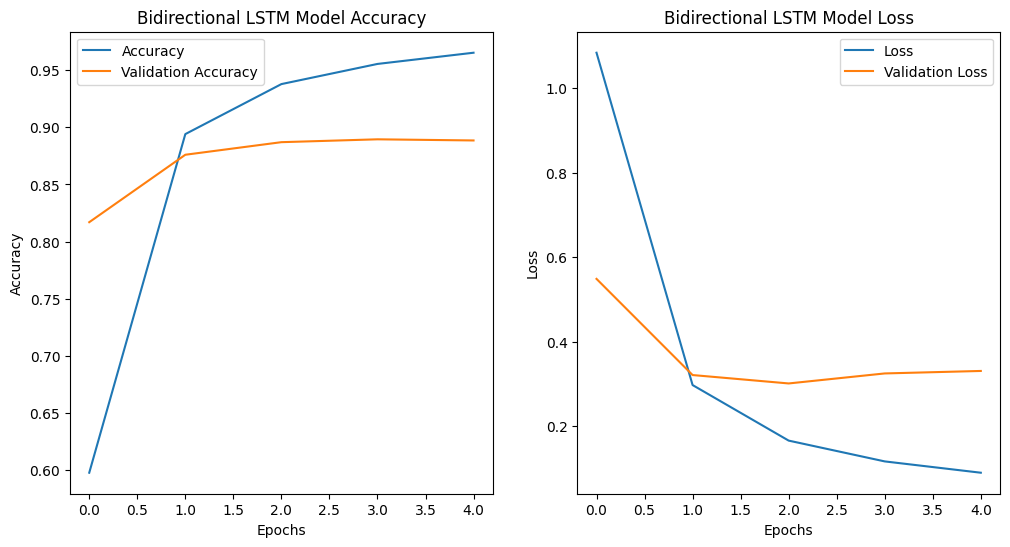

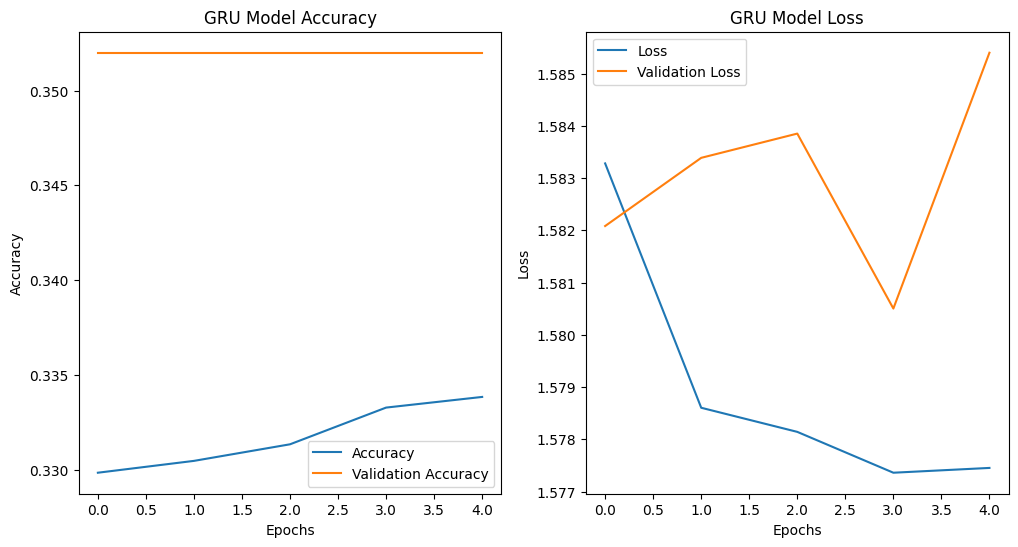

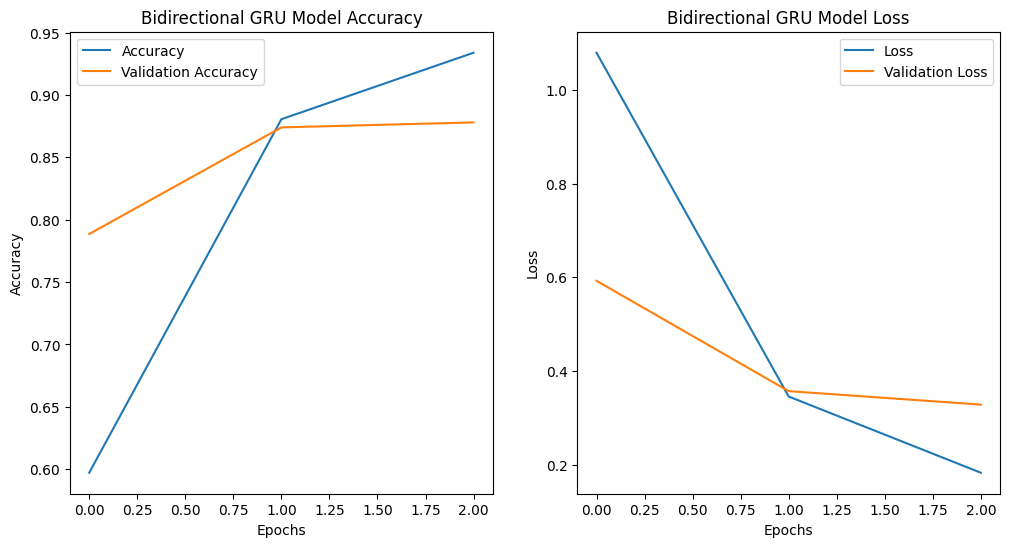

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Bidirectional LSTM Model Accuracy")
plt.plot(bidirectional_lstm_model_history.history["accuracy"], label="Accuracy")
plt.plot(
    bidirectional_lstm_model_history.history["val_accuracy"],
    label="Validation Accuracy",
)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()


# Plotting the loss plot of Bidirectional LSTM model
plt.subplot(1, 2, 2)
plt.title("Bidirectional LSTM Model Loss")
plt.plot(bidirectional_lstm_model_history.history["loss"], label="Loss")
plt.plot(bidirectional_lstm_model_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("GRU Model Accuracy")
plt.plot(gru_model_history.history["accuracy"], label="Accuracy")
plt.plot(gru_model_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Plotting the loss plot of GRU model
plt.subplot(1, 2, 2)
plt.title("GRU Model Loss")
plt.plot(gru_model_history.history["loss"], label="Loss")
plt.plot(gru_model_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plotting the accuracy plot of Bidirectional GRU model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Bidirectional GRU Model Accuracy")
plt.plot(bidirectional_gru_model_history.history["accuracy"], label="Accuracy")
plt.plot(
    bidirectional_gru_model_history.history["val_accuracy"], label="Validation Accuracy"
)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Plotting the loss plot of Bidirectional GRU model
plt.subplot(1, 2, 2)
plt.title("Bidirectional GRU Model Loss")
plt.plot(bidirectional_gru_model_history.history["loss"], label="Loss")
plt.plot(bidirectional_gru_model_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()


In [39]:
y_pred_bilstm = bidirectional_lstm_model.predict(x_test)
y_pred_bigru = bidirectional_gru_model.predict(x_test)
y_pred_gru = gru_model.predict(x_test)

y_pred_bilstm = np.argmax(y_pred_bilstm, axis=1)
y_pred_bigru = np.argmax(y_pred_bigru, axis=1)
y_pred_gru = np.argmax(y_pred_gru, axis=1)


63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [ ]:
result = {
    "Model Name": [
        "Bidirectional LSTM",
        "Bidirectional GRU",
        "GRU",
    ],
    "Accuracy Score": [
        accuracy_score(y_test, y_pred_bilstm),
        accuracy_score(y_test, y_pred_bigru),
        accuracy_score(y_test, y_pred_gru),
    ],
    "F1 Score(macro)": [
        f1_score(y_test, y_pred_bilstm, average="macro"),
        f1_score(y_test, y_pred_bigru, average="macro"),
        f1_score(y_test, y_pred_gru, average="macro"),
    ],
    "Recall Score(macro)": [
        recall_score(y_test, y_pred_bilstm, average="macro"),
        recall_score(y_test, y_pred_bigru, average="macro"),
        recall_score(y_test, y_pred_gru, average="macro"),
    ],
    "Precision Score(macro)": [
        precision_score(y_test, y_pred_bilstm, average="macro"),
        precision_score(y_test, y_pred_bigru, average="macro"),
        precision_score(y_test, y_pred_gru, average="macro"),
    ],
    "F1 Score(micro)": [
        f1_score(y_test, y_pred_bilstm, average="micro"),
        f1_score(y_test, y_pred_bigru, average="micro"),
        f1_score(y_test, y_pred_gru, average="micro"),
    ],
    "Recall Score(micro)": [
        recall_score(y_test, y_pred_bilstm, average="micro"),
        recall_score(y_test, y_pred_bigru, average="micro"),
        recall_score(y_test, y_pred_gru, average="micro"),
    ],
    "Precision Score(micro)": [
        precision_score(y_test, y_pred_bilstm, average="micro"),
        precision_score(y_test, y_pred_bigru, average="micro"),
        precision_score(y_test, y_pred_gru, average="micro"),
    ],
}

result_df = pd.DataFrame(result)

result_df.to_excel("Report of Trained Model.xlsx")


In [41]:
def predict_emotion_of_text(text):

    processed_text = text_preprocessing(text)
    ## the model has already learned to do fit_on_texts so dont do it again use it only during training
    text_to_sequence = tokenizer.texts_to_sequences([processed_text])[0]
    padded_sequence = pad_sequences([text_to_sequence], maxlen=50, padding="post")

    prediction = bidirectional_gru_model.predict(padded_sequence)[0]

    classes = ["sadness", "joy", "love", "anger", "fear", "surprise"]

    print("Input: ", text)
    print("Output: ", classes[np.argmax(prediction)])
    print("\n")


In [42]:
predict_emotion_of_text("Today is a bad day for me")
predict_emotion_of_text("she always gets angry if she doesn't get her own way")
predict_emotion_of_text("I love myself")
predict_emotion_of_text("What a beautiful day ")
predict_emotion_of_text("That horror movie is so scary")
predict_emotion_of_text("Wow! what a lovely surprise")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Input:  Today is a bad day for me
Output:  sadness


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Input:  she always gets angry if she doesn't get her own way
Output:  anger


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Input:  I love myself
Output:  love


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Input:  What a beautiful day 
Output:  joy


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Input:  That horror movie is so scary
Output:  sadness


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Input:  Wow! what a lovely surprise
Output:  surprise


